# Data Overview for Modelling and Simulation of Stochastic Processes
---

## 1st Dataset: Galapagos Albatrosses
Species Name: Phoebastria irrorata

**Dataset:**

* https://datarepository.movebank.org/entities/datapackage/b118f49f-6450-430d-b5f8-c455ff0292ae

**Publication**: 

reference: Dodge, S. et al. The environmental-data automated track annotation (Env-DATA) system: linking animal tracks with environmental data. Mov Ecol 1, 3 (2013).

* https://doi.org/10.1186/2051-3933-1-3


In [12]:
# Necessary Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

In [13]:
# plt style
plt.rcParams.update({
    "figure.dpi":150,
    "axes.spines.top":False,
    "axes.spines.right":False
})

# Seaborn style
PALETTE = sns.color_palette("tab10")

In [14]:
# Load data
DATA_PATH = (
    "/Users/julianyoo/Downloads/Study/PWR/Term 1/"
    "Computer Modelling and Simulation of Stochastic Processes/"
    "Project/data/galapagos_albatrosses/Galapagos Albatrosses.csv"
)

df = pd.read_csv(DATA_PATH)
print(f"{df.shape}")
print(df.dtypes.to_string())

(16414, 28)
event-id                               int64
timestamp                                str
location-long                        float64
location-lat                         float64
eobs:battery-voltage                   int64
eobs:fix-battery-voltage               int64
eobs:horizontal-accuracy-estimate    float64
eobs:key-bin-checksum                  int64
eobs:speed-accuracy-estimate         float64
eobs:start-timestamp                     str
eobs:status                              str
eobs:temperature                       int64
eobs:type-of-fix                       int64
eobs:used-time-to-get-fix              int64
ground-speed                         float64
heading                              float64
height-above-ellipsoid               float64
visible                                 bool
sensor-type                              str
individual-taxon-canonical-name          str
tag-local-identifier                   int64
individual-local-identifier              st

In [16]:
# Handling naming conventions
col_map = {}
for c in df.columns:
    cl = c.lower().strip()
    if cl == "timestamp":
        col_map[c] = "timestamp"
    elif "location-long" in cl or "longitude" in cl:
        col_map[c] = "lon"
    elif "location-lat" in cl or "latitude" in cl:
        col_map[c] = "lat"
    elif "individual-local-identifier" in cl or "individual.local.identifier" in cl:
        col_map[c] = "individual_id"
    elif "individual-taxon-canonical-name" in cl:
        col_map[c] = "taxon"
 
df.rename(columns=col_map, inplace=True)

# Parsing timestamp
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True, errors="coerce")
df.sort_values(["individual_id", "timestamp"], inplace=True)
df.reset_index(drop=True, inplace=True)

# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
miss_df = pd.DataFrame({"count": missing, "%": missing_pct})
print(miss_df[miss_df["count"] > 0].to_string() if miss_df["count"].sum() > 0
      else "There is no missing values")

                                   count     %
lon                                  386  2.35
lat                                  386  2.35
eobs:horizontal-accuracy-estimate    386  2.35
eobs:speed-accuracy-estimate         386  2.35
ground-speed                         386  2.35
heading                              386  2.35
height-above-ellipsoid               386  2.35
utm-easting                          386  2.35
utm-northing                         386  2.35
utm-zone                             386  2.35


In [17]:
# Date range for this dataset?
print(f"Star: {df['timestamp'].min()}")
print(f"End: {df['timestamp'].max()}")
print(f"Span: {(df['timestamp'].max() - df['timestamp'].min()).days} days")

Star: 2008-05-31 13:29:31.998000+00:00
End: 2008-11-06 18:00:55.998000+00:00
Span: 159 days


In [18]:
# Clean
missing_coords = df["lat"].isna() | df["lon"].isna()
df["_prev_missing"] = df.groupby("individual_id")["lat"].shift(1).isna()
df["_next_missing"] = df.groupby("individual_id")["lat"].shift(-1).isna()
gap_contaminated = df["_prev_missing"] | df["_next_missing"]
 
df_clean = df[~missing_coords & ~gap_contaminated].copy()
df_clean.drop(columns=["_prev_missing", "_next_missing"], inplace=True)
print(f"After co-ord cleaning : {len(df_clean):,} rows  "
      f"(removed {len(df) - len(df_clean):,})")

After co-ord cleaning : 15,579 rows  (removed 835)


In [19]:
# Compute the datetime and stpes again
df_clean = (df_clean
            .sort_values(["individual_id", "timestamp"])
            .reset_index(drop=True))
df_clean["dt_sec"] = (
    df_clean.groupby("individual_id")["timestamp"]
    .diff().dt.total_seconds()
)
 
median_dt = df_clean["dt_sec"].dropna().median()
cutoff_sec = median_dt * 10
large_gap = df_clean["dt_sec"] > cutoff_sec

print(f"Median fix interval: {median_dt/60:.1f} min")
print(f"Gap cutoff (10×): {cutoff_sec/3600:.2f} h  - "
      f"{large_gap.sum()} steps flagged and excluded from fitting")

Median fix interval: 90.0 min
Gap cutoff (10×): 15.00 h  - 13 steps flagged and excluded from fitting


In [20]:
# Helpers
def haversine_m(lat1, lon1, lat2, lon2):
    """Great-circle distance in metres"""
    R = 6_371_000
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlam = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlam/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

def turning_angles(lat, lon):
    """Signed turning angles in degrees for an ordered GPS sequence"""
    def bearing(la1, lo1, la2, lo2):
        la1, lo1, la2, lo2 = map(np.radians, [la1, lo1, la2, lo2])
        x = np.sin(lo2-lo1)*np.cos(la2)
        y = np.cos(la1)*np.sin(la2) - np.sin(la1)*np.cos(la2)*np.cos(lo2-lo1)
        return np.degrees(np.arctan2(x, y)) % 360
 
    n = len(lat)
    angles = np.full(n, np.nan)
    for i in range(1, n-1):
        b_in = bearing(lat[i-1], lon[i-1], lat[i], lon[i])
        b_out = bearing(lat[i], lon[i], lat[i+1], lon[i+1])
        angles[i] = ((b_out - b_in) + 180) % 360 - 180
    return angles

In [22]:
# Step lengths, speed, and turning angles
records = []
for bird, grp in df_clean.groupby("individual_id"):
    grp = grp.sort_values("timestamp").reset_index(drop=True)
    lat, lon = grp["lat"].values, grp["lon"].values
    n = len(grp)
 
    step_m   = np.full(n, np.nan)
    speed_ms = np.full(n, np.nan)
    for i in range(1, n):
        step_m[i] = haversine_m(lat[i-1], lon[i-1], lat[i], lon[i])
        if grp["dt_sec"].iloc[i] > 0:
            speed_ms[i] = step_m[i] / grp["dt_sec"].iloc[i]
 
    grp["step_m"] = step_m
    grp["speed_ms"] = speed_ms
    grp["turn_angle"] = turning_angles(lat, lon)
    records.append(grp)
 
df_clean = pd.concat(records, ignore_index=True)

large_gap_idx = df_clean.index[large_gap.reindex(df_clean.index, fill_value=False)]
steps = (
    df_clean
    .dropna(subset=["step_m", "dt_sec"])
    .query("step_m > 0 and dt_sec > 0 and step_m < 500_000")  # drop GPS outliers
    .drop(index=large_gap_idx, errors="ignore")
    .copy()
)
print(f"Valid steps for fitting: {len(steps):,}")

Valid steps for fitting: 15,538


In [ ]:
# Bird summary
birds = df_clean["individual_id"].unique()
colors = {b: PALETTE[i%10] for i,b in enumerate(birds)}

bird_summary = (
    df_clean.groupby("individual_id").agg(n_fixes=("timestamp","count"),
                                          start=("timestamp","min"),
                                          end=("timestamp","max"))
)
bird_summary["duration_days"] = ((bird_summary["end"] - bird_summary["start"]).dt.total_seconds() / 86400).round(1)

step_summary = (
    steps.groupby("individual_id").agg(n_steps =("step_m","count"),
                                       mean_km =("step_m", lambda x: (x/1000).mean()),
                                       median_km =("step_m", lambda x: (x/1000).median()),
                                       max_km =("step_m", lambda x: (x/1000).max()),
                                       std_km =("step_m", lambda x: (x/1000).std()),
                                       median_dt_h =("dt_sec", lambda x: (x/3600).median()),
                                       mean_speed_ms=("speed_ms","mean")).round(3)
)
print(f"Individual bird summary")
print(bird_summary[["n_fixes","duration_days","start","end"]].to_string())
print(f"\nStep length summary")
print(step_summary.to_string())

Individual bird summary
                 n_fixes  duration_days                            start                              end
individual_id                                                                                            
1094-1094             46            2.8 2008-06-23 16:30:08.998000+00:00 2008-06-26 12:00:20.999000+00:00
1103-1103            110           17.6 2008-06-23 18:01:27.998000+00:00        2008-07-11 09:02:30+00:00
1163-1163           1473           96.8 2008-06-23 18:01:01.001000+00:00 2008-09-28 12:01:50.999000+00:00
2131-2131            635           40.6 2008-06-23 19:30:08.999000+00:00 2008-08-03 09:00:19.998000+00:00
2368-2368             30            1.8 2008-06-23 18:01:09.998000+00:00 2008-06-25 13:30:44.998000+00:00
2382-2382             65            4.0 2008-06-23 18:00:08.998000+00:00 2008-06-27 18:00:56.001000+00:00
3272-3272            187           11.6 2008-06-23 19:30:06.999000+00:00 2008-07-05 10:30:56.001000+00:00
3275-30662          13

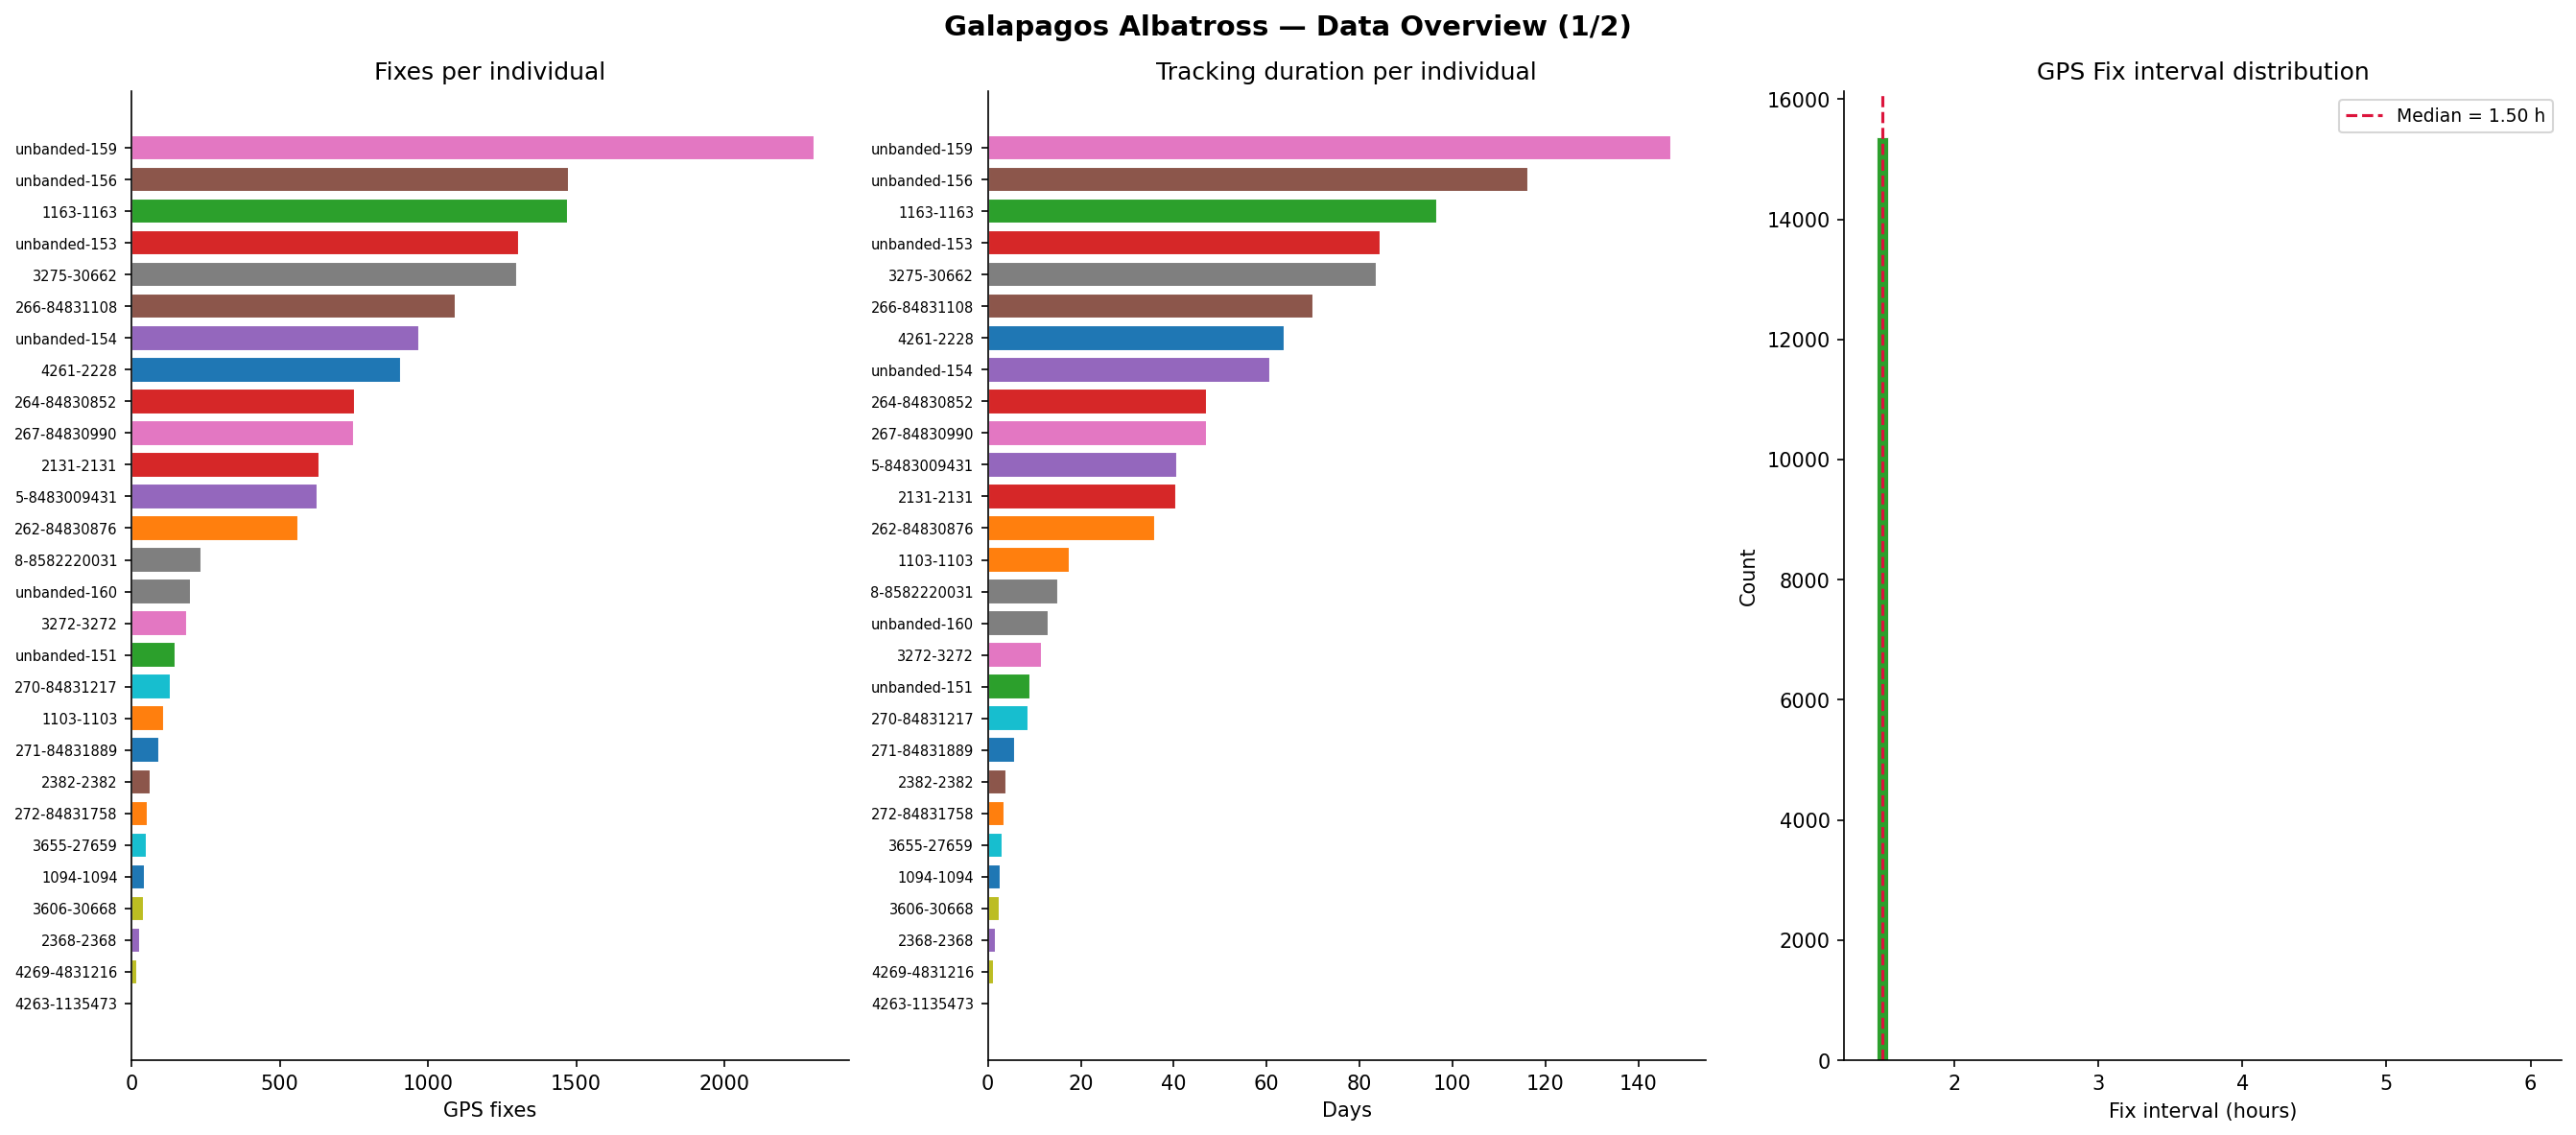

In [44]:
fig1, axes = plt.subplots(1, 3, figsize=(18, 8))
fig1.suptitle("Galapagos Albatross — Data Overview (1/2)", fontsize=14, fontweight="bold", y=0.98)

# Individual figure
ax = axes[0]
cnt = bird_summary["n_fixes"].sort_values()
ax.barh(range(len(cnt)), cnt.values,
        color=[colors[b] for b in cnt.index], edgecolor="white")
ax.set_yticks(range(len(cnt)))
ax.set_yticklabels([str(b)[-12:] for b in cnt.index], fontsize=7)
ax.set_xlabel("GPS fixes")
ax.set_title("Fixes per individual")

# Tracking duration
ax = axes[1]
dur = bird_summary["duration_days"].sort_values()
ax.barh(range(len(dur)), dur.values,
        color=[colors[b] for b in dur.index], edgecolor="white")
ax.set_yticks(range(len(dur)))
ax.set_yticklabels([str(b)[-12:] for b in dur.index], fontsize=7)
ax.set_xlabel("Days")
ax.set_title("Tracking duration per individual")

# GPS fix invertal distribution
ax = axes[2]
dt_hr = steps["dt_sec"] / 3600
ax.hist(dt_hr[dt_hr < dt_hr.quantile(0.99)], bins=60,
        color=PALETTE[2], edgecolor="white", linewidth=0.4)
ax.axvline(dt_hr.median(), color="crimson", linestyle="--", linewidth=1.5,
           label=f"Median = {dt_hr.median():.2f} h")
ax.set_xlabel("Fix interval (hours)")
ax.set_ylabel("Count")
ax.set_title("GPS Fix interval distribution")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

**First Figure**

- the dataset has an imbalance issue. For Levy flight fitting, individuals fewer than (lets say ~500) are borderline.

**Second Figure**

- the longest tracked two categories of birds cover ~120 to ~ 159 days. Which implies they were tracked from June - November. General pattern between fixes - duration ranks in the same order.

- (short fixes): gives good statistic but only on behavioural phase

- (long track): transition between incubation and early chick-rearing and later chick-rearing -> they may have different movement purposes.

`This is to be discussed`

**Thrid Figure**

- nearly the entire distribution sits at 1.5 hrs. This implies a nearly perfectly regular smapling clock -> every step length measures displacement over the same time window. -> The step lengths are direclty comparable across individuals and across time wihtout any need on time normalising tehcnique.

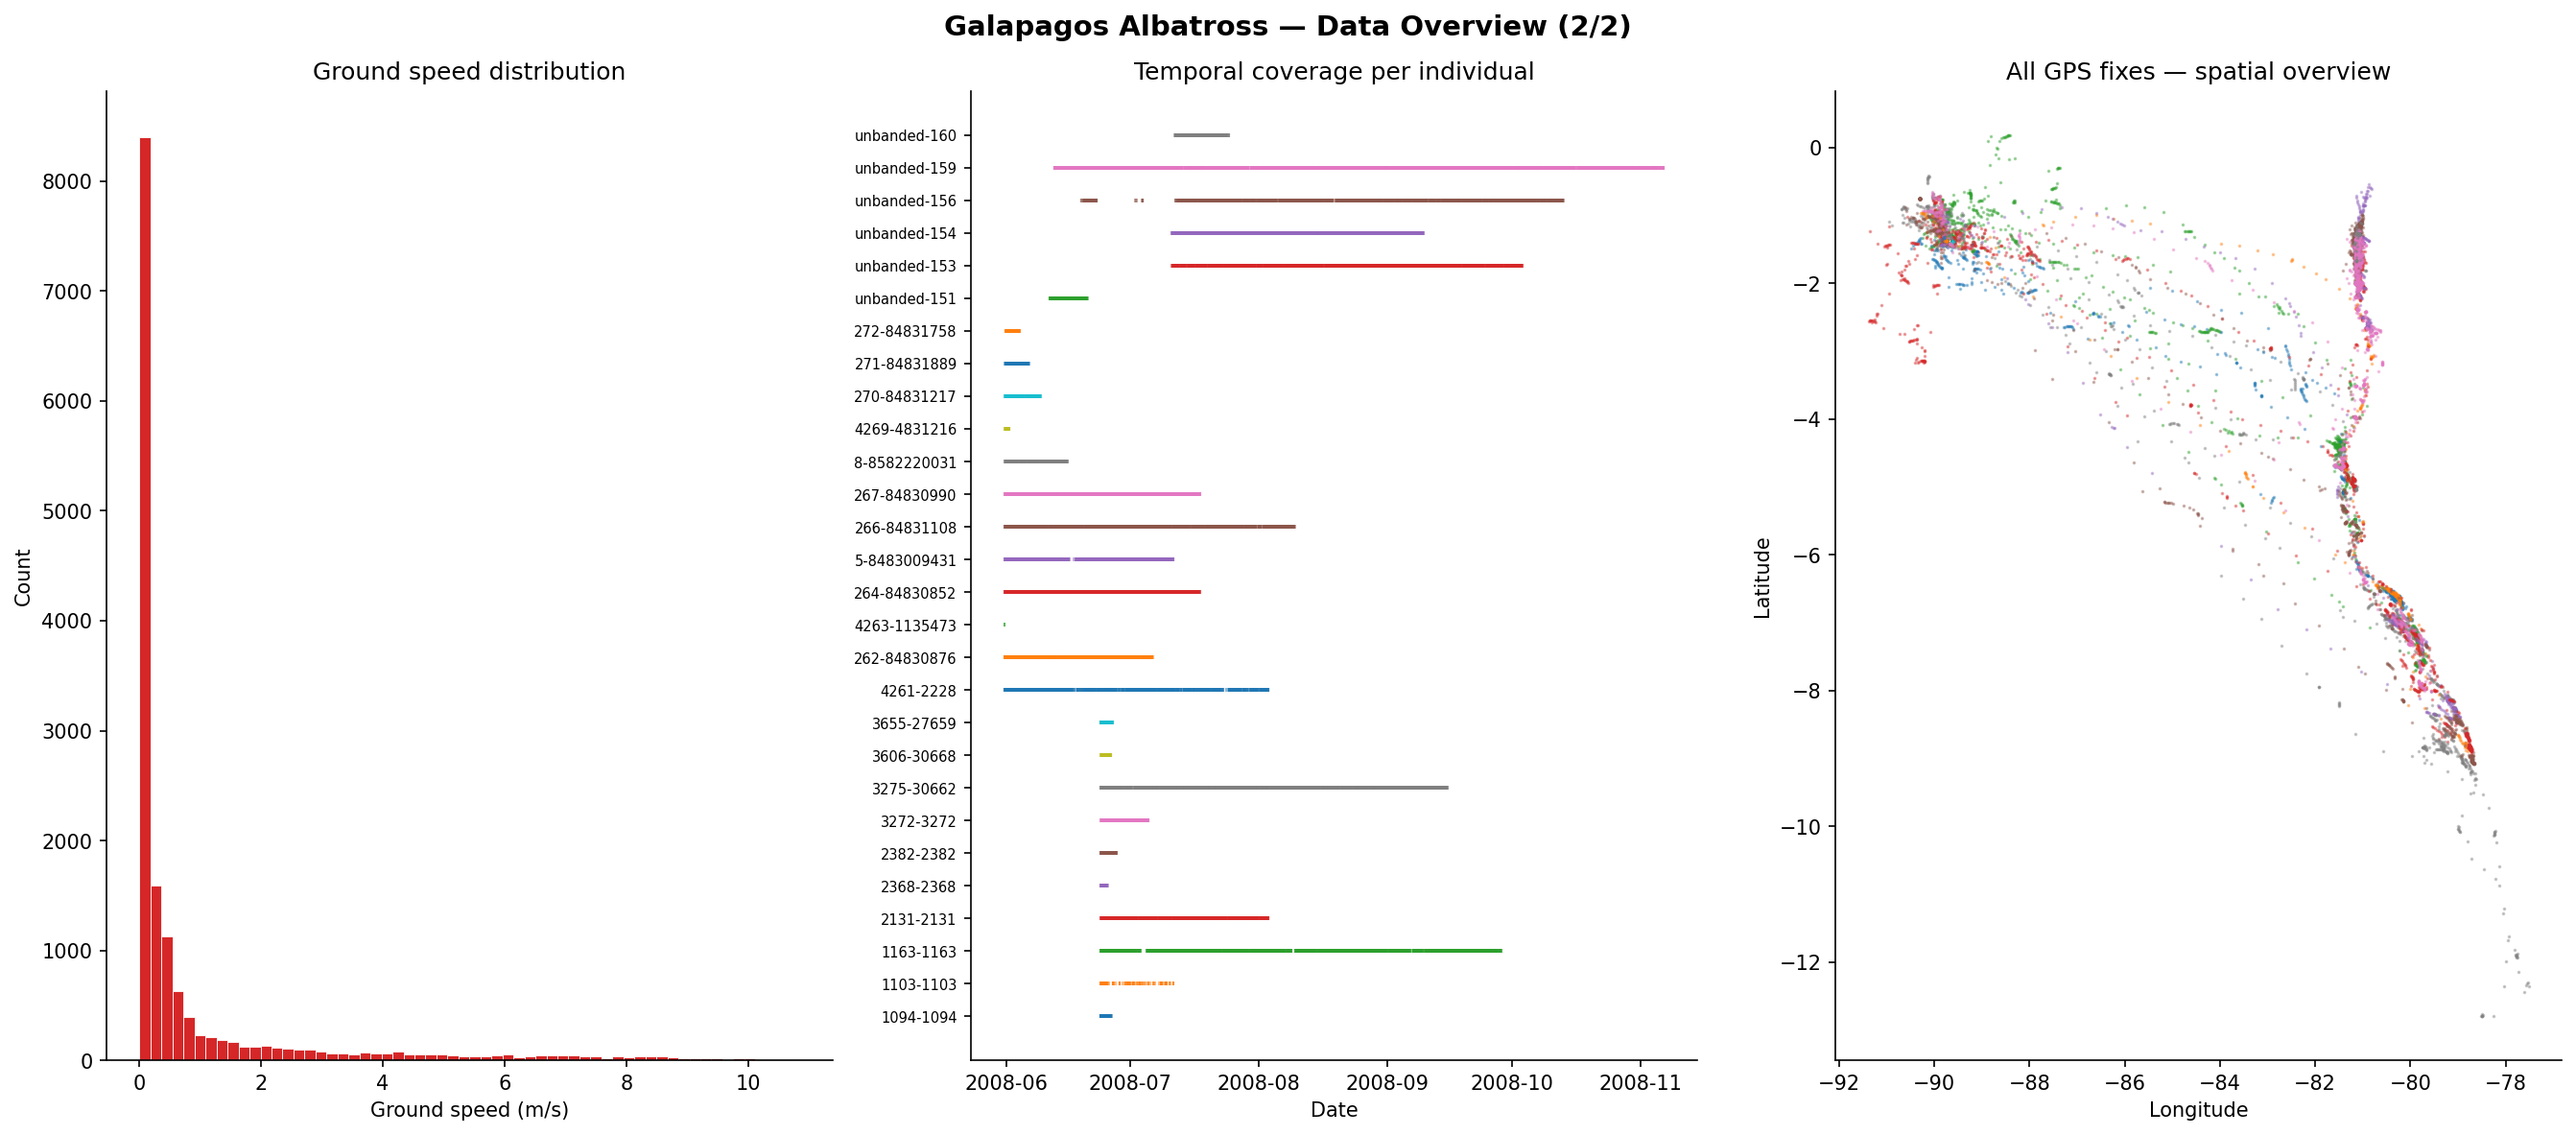

In [46]:
fig2, axes = plt.subplots(1, 3, figsize=(18, 8))
fig2.suptitle("Galapagos Albatross — Data Overview (2/2)", fontsize=14, fontweight="bold", y=0.98)

# Ground speed distribution
ax = axes[0]
spd = steps["speed_ms"].dropna()
ax.hist(spd[spd < spd.quantile(0.99)], bins=60,
        color=PALETTE[3], edgecolor="white", linewidth=0.4)
ax.set_xlabel("Ground speed (m/s)")
ax.set_ylabel("Count")
ax.set_title("Ground speed distribution")

# Coverage
ax = axes[1]
bird_list = list(df_clean["individual_id"].unique())
for idx, (bird, grp) in enumerate(df_clean.groupby("individual_id")):
    ax.plot(grp["timestamp"], [idx] * len(grp),
            "|", color=colors[bird], markersize=2, alpha=0.5)
ax.set_yticks(range(len(bird_list)))
ax.set_yticklabels([str(b)[-12:] for b in bird_list], fontsize=7)
ax.set_xlabel("Date")
ax.set_title("Temporal coverage per individual")
fig1.autofmt_xdate()

# Spatial
ax = axes[2]
for bird, grp in df_clean.groupby("individual_id"):
    ax.scatter(grp["lon"], grp["lat"], s=0.5,
               color=colors[bird], alpha=0.4, label=str(bird)[-12:])
ax.set_xlabel("Longitude");  ax.set_ylabel("Latitude")
ax.set_title("All GPS fixes — spatial overview")

plt.tight_layout()
plt.show()

**Fourth Figure**

- the distribution is strongly right-skewed

    - the peak is near 0 m/s -> birds sit stationary the most time

    - the tail -> the moments of active flights. 

**Fifth Figure**

- unbanded-159 has the longest unbroken coverage. The most valuable birds

**Sixth Figure**

- the dense cluster at longitude: -90 to -90 and latitude: -1 to -2 is the galapagos islands. Every bird returns here repeatedly

- the westward scatters to (-92): This is to the Pacific. This may represent the purpose of foraging. "heavy-tailed dist"?

- the southward scatters to (longtidue: -78 to -82 and latitude: -4 to -13): This might be the best to be reproduced with Levy - The reference paper used Levy and Brownian on this cluster and the galapos islands.

---
## 2nd Dataset: White Stork

Species Name: Ciconia ciconia



**Dataset:**

* https://datarepository.movebank.org/entities/datapackage/5f8c5199-c2b0-4e48-9521-8c5d5f6b115c

**Publication:**

Cheng, Y. etal. “Closer-to-home” strategy benefits juvenile survival in a long-distance migratory bird. Ecol Evol. 2019;9:8945–8952. https://doi.org/10.1002/ece3.5395


* https://onlinelibrary.wiley.com/doi/10.1002/ece3.5395

Andrea Flack et al. ,Costs of migratory decisions: A comparison across eight white stork populations.Sci. Adv.2,e1500931(2016).DOI:10.1126/sciadv.1500931

* https://www.science.org/doi/10.1126/sciadv.1500931

Weinzierl, R. et al. (2016), Wind estimation based on thermal soaring of birds. Ecology and Evolution, 6: 8706–8718. doi: 10.1002/ece3.2585

* https://onlinelibrary.wiley.com/doi/10.1002/ece3.2585

Kays, R. et al. (2022). The Movebank system for studying global animal movement and demography. Methods in Ecology and Evolution, 13, 419–431. https://doi.org/10.1111/2041-210X.13767

* https://besjournals.onlinelibrary.wiley.com/doi/10.1111/2041-210X.13767


In [1]:
# Necessary Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")